<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Clustering/Clustering_Mall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Algorithms: A Detailed Exploration

Clustering is an unsupervised machine learning technique used to group data points into clusters such that data points within the same cluster are more similar to each other than to those in other clusters. Unlike supervised learning, there are no predefined labels or target variables; the algorithm discovers intrinsic groupings in the data.

### Key Concepts:

1.  **Similarity Measure**: How the distance or resemblance between data points is quantified (e.g., Euclidean distance, cosine similarity).
2.  **Centroid/Medoid**: A representative point of a cluster, often the mean or a central data point.
3.  **Evaluation Metrics**: Methods to assess the quality of clusters (e.g., Silhouette Score, Davies-Bouldin Index).

In this notebook, we will explore the following clustering algorithms in detail, covering their intuition, mathematical foundations, and practical application using the **Mall Customer Segmentation Data**:

*   **Partition-Based**: K-Means
*   **Hierarchical**: Agglomerative
*   **Density-Based**: DBSCAN
*   **Model-Based**: Gaussian Mixture Model (GMM)


## 1. Data Loading and Initial Exploration

First, let's load the Mall Customer Segmentation dataset and perform some initial exploration to understand its structure and features.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the dataset
data_url = 'https://raw.githubusercontent.com/rsys-adsingh/Machine-Learning/main/study/Clustering/Mall_Customers.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
display(df.head())

# Display basic information about the dataset
print(df.info())

# Display descriptive statistics
display(df.describe())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Data Preprocessing and Visualization

Before applying clustering algorithms, it's essential to preprocess the data. This often involves handling categorical variables, scaling numerical features, and visualizing the data to gain insights into its structure.

First, we'll convert the 'Gender' column into a numerical format using one-hot encoding, and then we'll visualize the distribution of key features.

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Is_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


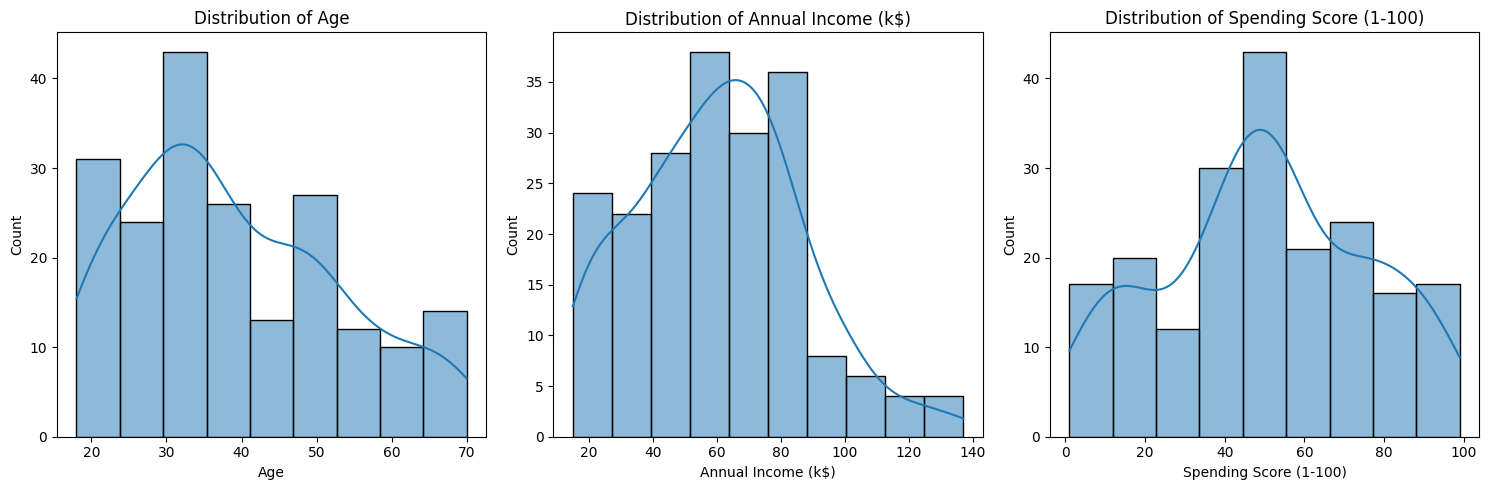

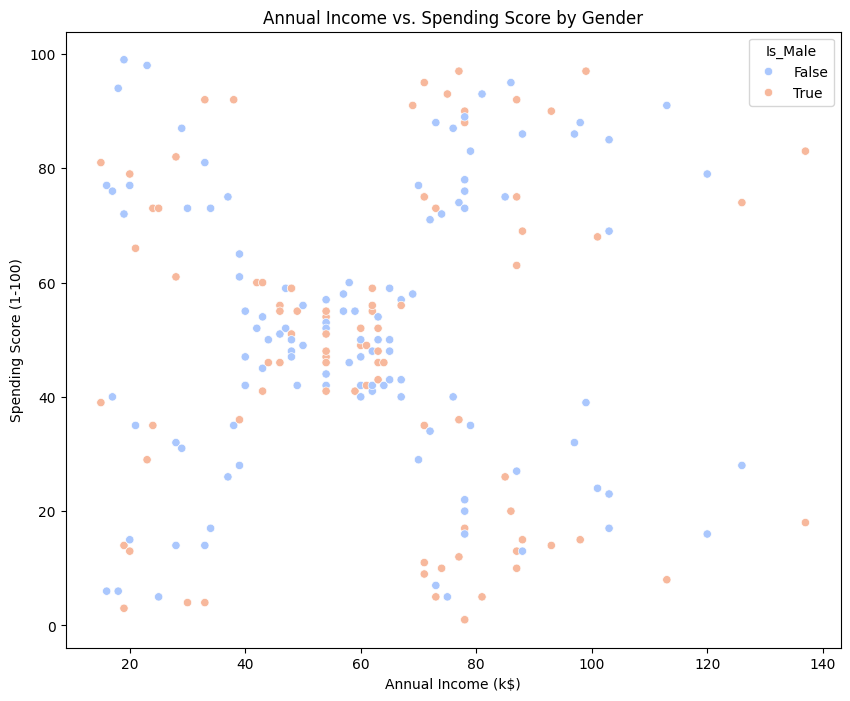

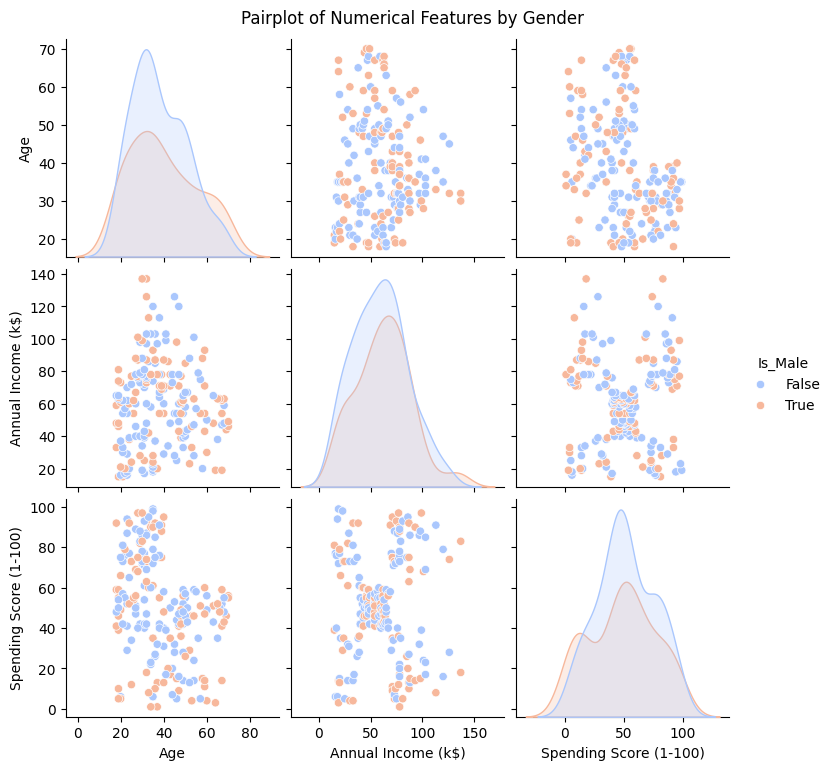

In [72]:
# One-hot encode the 'Gender' column
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True) # drop_first avoids multicollinearity

# Rename the new Gender column for clarity
df_encoded.rename(columns={'Gender_Male': 'Is_Male'}, inplace=True)

display(df_encoded.head())

# Visualize the distribution of numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_encoded['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df_encoded['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.histplot(df_encoded['Spending Score (1-100)'], kde=True)
plt.title('Distribution of Spending Score (1-100)')

plt.tight_layout()
plt.show()

# Visualize relationships between key features
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_encoded, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Is_Male', palette='coolwarm')
plt.title('Annual Income vs. Spending Score by Gender')
plt.show()

sns.pairplot(df_encoded[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']], hue='Is_Male', palette='coolwarm')
plt.suptitle('Pairplot of Numerical Features by Gender', y=1.02)
plt.show()

### Feature Scaling

Clustering algorithms that rely on distance metrics (like K-Means, Agglomerative, DBSCAN) are sensitive to the scale of the features. Features with larger values can dominate the distance calculations, leading to biased results. To prevent this, we will apply `StandardScaler` to normalize our numerical features (Age, Annual Income, Spending Score). We will not scale `CustomerID` as it's an identifier, nor `Is_Male` as it's already binary.

We will focus on `Annual Income (k$)` and `Spending Score (1-100)` for our primary clustering visualizations, as they showed the most prominent cluster structures.

In [73]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering. We'll mainly focus on Annual Income and Spending Score for initial clustering
# as they showed clear clusters in the scatter plot.
features_for_clustering = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df_encoded[features_for_clustering]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

display(X_scaled_df.head())

# You can also add the 'Is_Male' column back if you plan to use it in clustering
# X_scaled_df['Is_Male'] = df_encoded['Is_Male'].values

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 3. Partition-Based Clustering: K-Means

### 3.1 What is K-Means?
K-Means is one of the most popular unsupervised machine learning algorithms. It is a distance-based, partition-oriented algorithm that groups $n$ observations into $K$ pre-defined clusters.

### 3.2 Why K-Means?
It is favored for its simplicity, speed, and efficiency on large datasets. It provides a clear way to find local optimal solutions for grouping similar data points together.

### 3.3 What is K?
$K$ represents the number of clusters or groups the user wants to identify in the data. It is a hyperparameter that must be specified before the algorithm begins.

### 3.4 Centroid
A centroid is the arithmetic mean position of all the points in a cluster. It serves as the 'center' or representative point for that group.

### 3.5 Objective Function (WCSS)
The goal of K-Means is to minimize the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**:
$$ J = \sum_{i=1}^{n} \sum_{k=1}^{K} w_{ik} ||x_i - \mu_k||^2 $$
This function calculates the sum of squared distances between each data point and its assigned cluster centroid.

### 3.6 Algorithm Working
The algorithm follows an iterative process called **Lloyd's Algorithm**, which alternates between assigning points and updating centers.

### 3.7 Assignment Step
Each data point is assigned to the cluster with the nearest centroid based on the Euclidean distance:
$$ c^{(i)} := \text{arg min}_j ||x^{(i)} - \mu_j||^2 $$

### 3.8 Update Step
The centroids are moved to the mean of all points assigned to that cluster:
$$ \mu_j := \frac{\sum_{i=1}^n 1\{c^{(i)} = j\}x^{(i)}}{\sum_{i=1}^n 1\{c^{(i)} = j\}} $$

### 3.9 Convergence
The algorithm repeats the assignment and update steps until:
1. Centroids no longer change.
2. Assignments remain the same.
3. The maximum number of iterations is reached.

### 3.10 Choosing K
*   **WCSS**: Measures how compact the clusters are.
*   **Elbow Method**: We plot WCSS vs $K$. The 'elbow' is the point where the rate of decrease in WCSS drops sharply, indicating the optimal $K$.

### 3.11 K-Means++
*   **Random Initialization**: Choosing initial centroids randomly can lead to poor local optima.
*   **K-Means++**: An advanced initialization strategy that spreads out the initial centroids by picking points proportionally to their distance from existing centroids, leading to faster and better convergence.

### 3.12 Cluster Evaluation
*   **Inertia**: Lower inertia means more compact clusters.
*   **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters (ranges from -1 to 1).

### 3.13 Time Complexity
The complexity is $O(n \cdot K \cdot I \cdot d)$, making it linear with respect to the number of data points $n$.

### 3.14 Advantages
*   Scales to large data.
*   Efficient and easy to interpret.
*   Guaranteed convergence.

### 3.15 Limitations
*   Sensitive to outliers.
*   Must specify $K$ manually.
*   Struggles with non-spherical shapes (e.g., elongated or nested clusters).

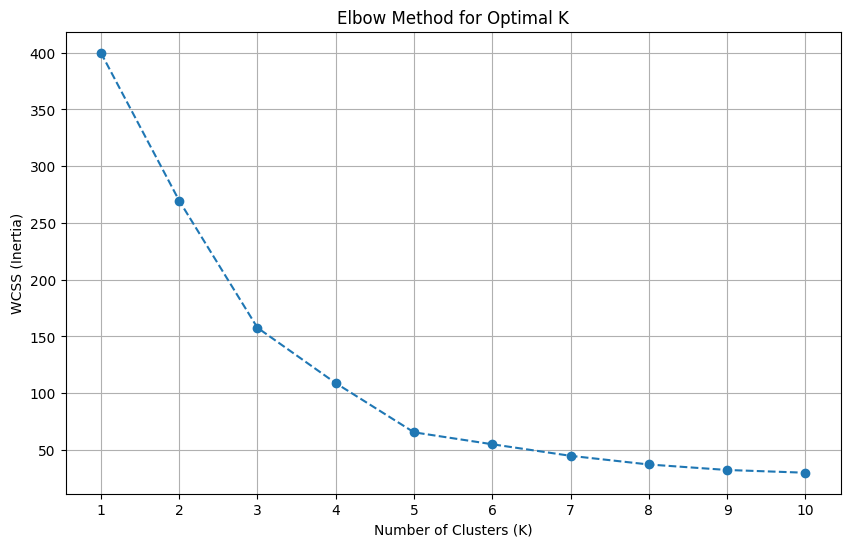

In [74]:
from sklearn.cluster import KMeans

# Select the features Annual Income and Spending Score for clustering for visualization purposes
X_2d = X_scaled_df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = [] # Within-Cluster Sum of Squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Applying K-Means with Optimal K

Based on the Elbow Method, we choose **K=5** as the optimal number of clusters. Let's now apply K-Means with 5 clusters to the `Annual Income (k$)` and `Spending Score (1-100)` features and visualize the clusters.

Inertia (WCSS):  65.57
Average Silhouette Score:  0.55


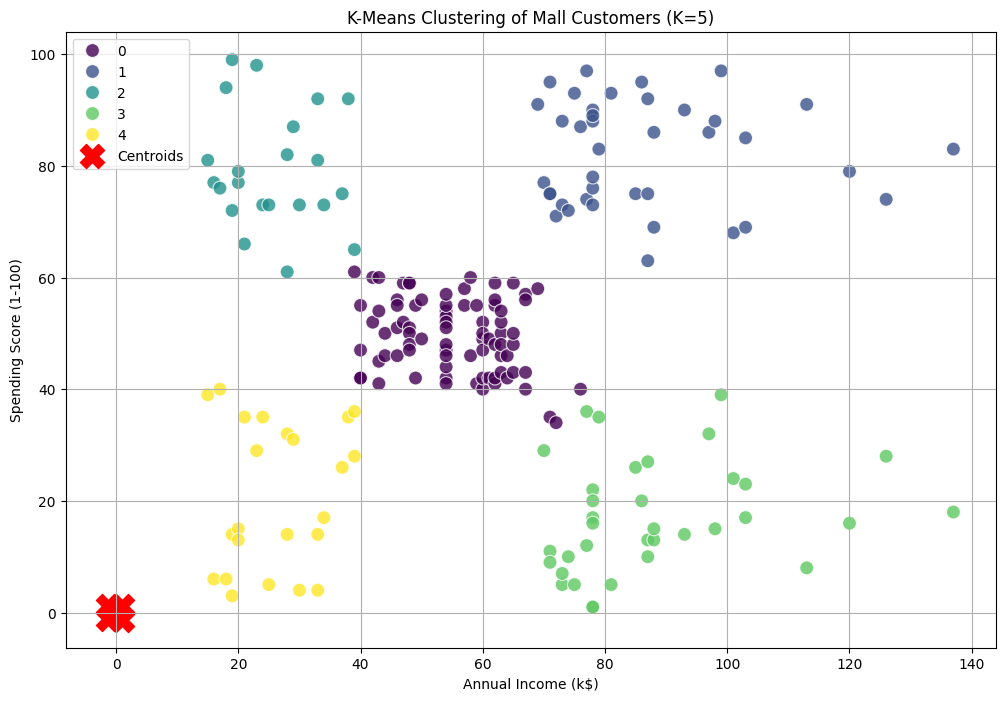

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 3.10 & 3.11: Applying K-Means with K=5 and K-Means++ initialization
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# 3.7 & 3.8: The fit_predict method executes the Assignment and Update steps iteratively
y_kmeans = kmeans.fit_predict(X_2d)

# Add labels to the dataframe
df_encoded['Cluster'] = y_kmeans

# 3.12: Evaluation Metrics
print(f"Inertia (WCSS): {kmeans.inertia_: .2f}")
sil_avg = silhouette_score(X_2d, y_kmeans)
print(f"Average Silhouette Score: {sil_avg: .2f}")

# Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)

# 3.4: Plotting the Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('K-Means Clustering of Mall Customers (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting K-Means Clusters

Let's analyze the characteristics of each cluster to understand the different customer segments identified by K-Means.

In [76]:
# Group by cluster and calculate the mean of the original (unscaled) features
cluster_means = df_encoded.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(cluster_means)

# You can also look at the size of each cluster
display(df_encoded['Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
Cluster,,,,
0,42.716049,55.296296,49.518519,0.407407
1,32.692308,86.538462,82.128205,0.461538
2,25.272727,25.727273,79.363636,0.409091
3,41.114286,88.200000,17.114286,0.542857
4,45.217391,26.304348,20.913043,0.391304


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


## 4. Hierarchical Clustering: Agglomerative

### 4.1 What is Hierarchical Clustering?

Hierarchical Clustering is an **unsupervised learning algorithm** that builds a hierarchy (tree) of clusters instead of creating all clusters at once like K-Means.

> Build small clusters first and keep merging them until all points become one cluster.

### 4.2 Why Hierarchical Clustering?
K-Means requires specifying **K** before training. Hierarchical Clustering doesn't. It builds the complete hierarchy first, and we decide later where to cut the tree.

### 4.3 Types of Hierarchical Clustering
- **Agglomerative (Bottom-Up)**: Every point starts as its own cluster. Most commonly used.
- **Divisive (Top-Down)**: Start with one cluster and split. Rarely used.

### 4.4 Intuition
Imagine students entering a classroom. Initially, everyone stands alone. Students with similar interests form groups. Small groups merge into larger groups. Eventually, everyone belongs to one large group.

### 4.5 Working
1. Start with N clusters (each point is a cluster).
2. Compute distances between all clusters.
3. Merge the two closest clusters.
4. Update distances.
5. Repeat until only one cluster remains.

### 4.6 Dendrogram
A **Dendrogram** is a tree diagram showing how clusters merge. Height represents the distance at which clusters merge. Lower merge = More Similar.

### 4.7 Linkage Methods
- **Single Linkage**: Uses the minimum distance (Nearest Neighbor).
- **Complete Linkage**: Uses the maximum distance (Farthest Neighbor).
- **Average Linkage**: Uses average pairwise distance.
- **Ward Linkage** : Minimizes the increase in variance after merging. This is the default choice for compact clusters.

### 4.11 Time Complexity
Building hierarchy is $O(n^2 \log n)$ with $O(n^2)$ memory. It is slower than K-Means and suitable for small to medium datasets.

### 4.15 K-Means vs Agglomerative

| Feature | K-Means | Agglomerative |
| :--- | :--- | :--- |
| Need K Before Training | Yes | No |
| Cluster Shape | Mostly Spherical | More Flexible |
| Speed | Fast | Slow |
| Dendrogram | No | Yes |
| Large Dataset | Excellent | Poor |

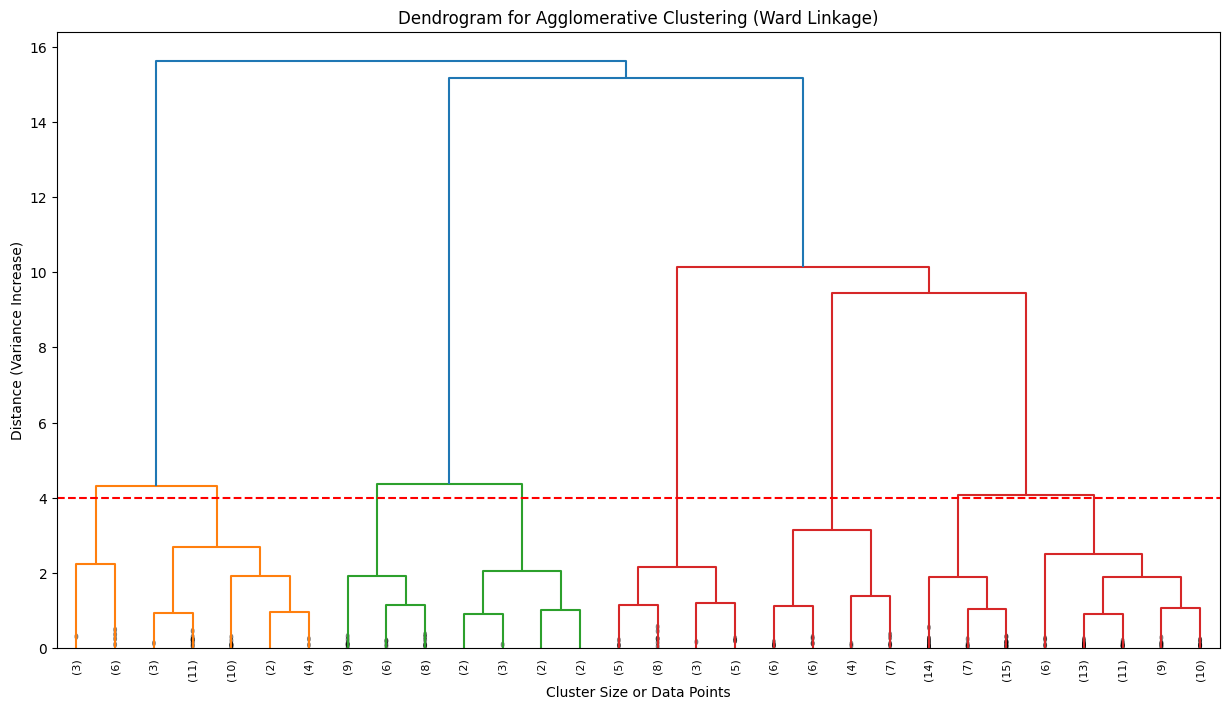

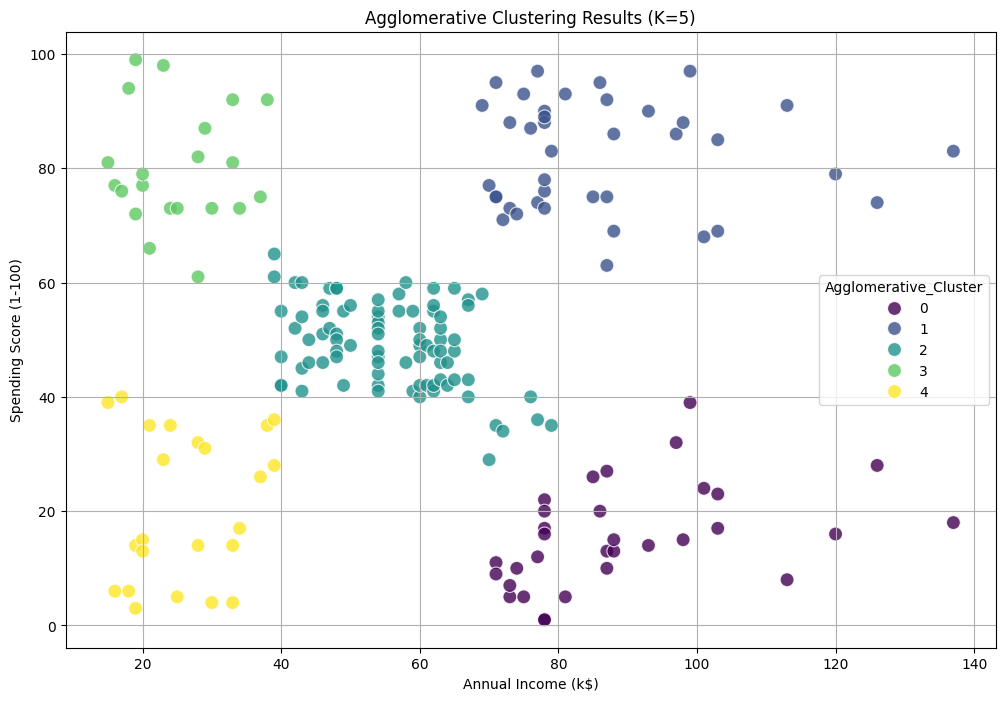

In [77]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 4.5 & 4.7: Generate the linkage matrix using Ward Linkage
# This step calculates distances and builds the merge history
Z = linkage(X_2d, method='ward')

# 4.6: Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,
)
plt.title('Dendrogram for Agglomerative Clustering (Ward Linkage)')
plt.xlabel('Cluster Size or Data Points')
plt.ylabel('Distance (Variance Increase)')
plt.axhline(y=4, color='r', linestyle='--') # 4.9: Visualizing the cut level
plt.show()

# 4.8 & 4.14: Applying Agglomerative Clustering
# We cut the tree at n_clusters=5 based on our analysis
n_clusters_agg = 5
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')

# Final clusters formed after cutting the dendrogram
df_encoded['Agglomerative_Cluster'] = agg_clustering.fit_predict(X_2d)

# Visualize the result
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglomerative_Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)
plt.title(f'Agglomerative Clustering Results (K={n_clusters_agg})')
plt.grid(True)
plt.show()

### Interpreting Agglomerative Clusters

Let's examine the characteristics of the clusters identified by Agglomerative Clustering and compare them with K-Means.

In [78]:
from sklearn.cluster import AgglomerativeClustering

# Group by Agglomerative cluster and calculate the mean of the original (unscaled) features

# Check if 'Agglomerative_Cluster' column exists. If not, re-run the clustering step.
if 'Agglomerative_Cluster' not in df_encoded.columns:
    print("Column 'Agglomerative_Cluster' not found. Re-running Agglomerative Clustering.")
    # Assuming X_2d and n_clusters_agg are available from previous cells.
    # If not, these lines might need to be adapted or preceding cells executed.
    n_clusters_agg = 5 # Defaulting to 5 clusters as determined previously
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
    df_encoded['Agglomerative_Cluster'] = agg_clustering.fit_predict(X_2d)

agg_cluster_means = df_encoded.groupby('Agglomerative_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(agg_cluster_means)

# You can also look at the size of each cluster
display(df_encoded['Agglomerative_Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
Agglomerative_Cluster,,,,
0,41.000000,89.406250,15.593750,0.562500
1,32.692308,86.538462,82.128205,0.461538
2,42.482353,55.811765,49.129412,0.400000
3,25.333333,25.095238,80.047619,0.428571
4,45.217391,26.304348,20.913043,0.391304


,count
Agglomerative_Cluster,
0,32
1,39
2,85
3,21
4,23


## 5. Density-Based Clustering: DBSCAN

### 5.1 What is DBSCAN?
Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is an **unsupervised learning algorithm** that finds clusters based on the density of data points.

### 5.2 Why DBSCAN?
Unlike K-Means, DBSCAN:
- Does not require you to specify **K** (number of clusters) beforehand.
- Can find clusters of **arbitrary shapes** (e.g., moons, circles).
- Is robust to **outliers** and noise.

### 5.3 Core Point
A point that has at least `MinPts` within its ε-radius (including itself).

### 5.4 Border Point
A point that has fewer than `MinPts` in its radius but is within the ε-neighborhood of a Core Point.

### 5.5 Noise Point
Any point that is neither a Core point nor a Border point. These are treated as outliers (-1).

### 5.6 ε (eps)
The maximum distance between two samples for one to be considered as in the neighborhood of the other.

### 5.7 MinPts (min_samples)
The minimum number of points required to form a dense region (a cluster).

### 5.8 Algorithm
1. Select an unvisited point.
2. Retrieve its ε-neighborhood.
3. If it has enough points (`MinPts`), a cluster is started; otherwise, mark as noise.
4. If a cluster starts, expand it (see 5.9).

### 5.9 Cluster Expansion
For a Core Point, all points in its neighborhood are added to the cluster. If those neighbors are also Core Points, their own neighborhoods are recursively added, allowing the cluster to grow as long as high density continues.

### 5.11 K-Means vs Hierarchical vs DBSCAN

| Feature | K-Means | Hierarchical | DBSCAN |
| :--- | :--- | :--- | :--- |
| **Specifying K** | Required | Not required | Not required |
| **Cluster Shape** | Spherical | Flexible | Arbitrary/Density-based |
| **Noise Handling** | Poor (Outliers pulled in) | Moderate | Excellent (Labels as -1) |
| **Complexity** | $O(n)$ | $O(n^2)$ | $O(n \log n)$ |
| **Sensitivity** | Centroid init | Linkage type | ε and MinPts values |

### 5.12 Advantages
- No need to pre-specify the number of clusters.
- Identifies noise/outliers automatically.
- Works for non-linear data distributions.

### 5.13 Limitations
- Fails if the dataset has varying densities.
- Sensitive to the choice of distance metric and ε.

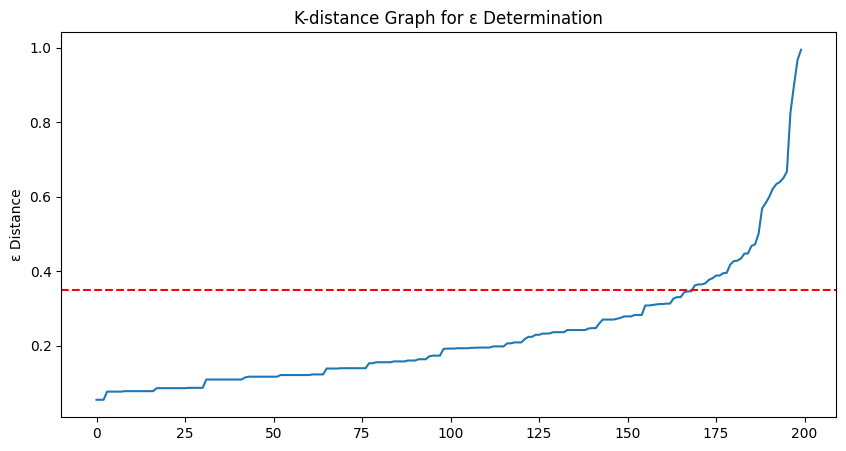

Estimated clusters: 8
Noise points detected: 16


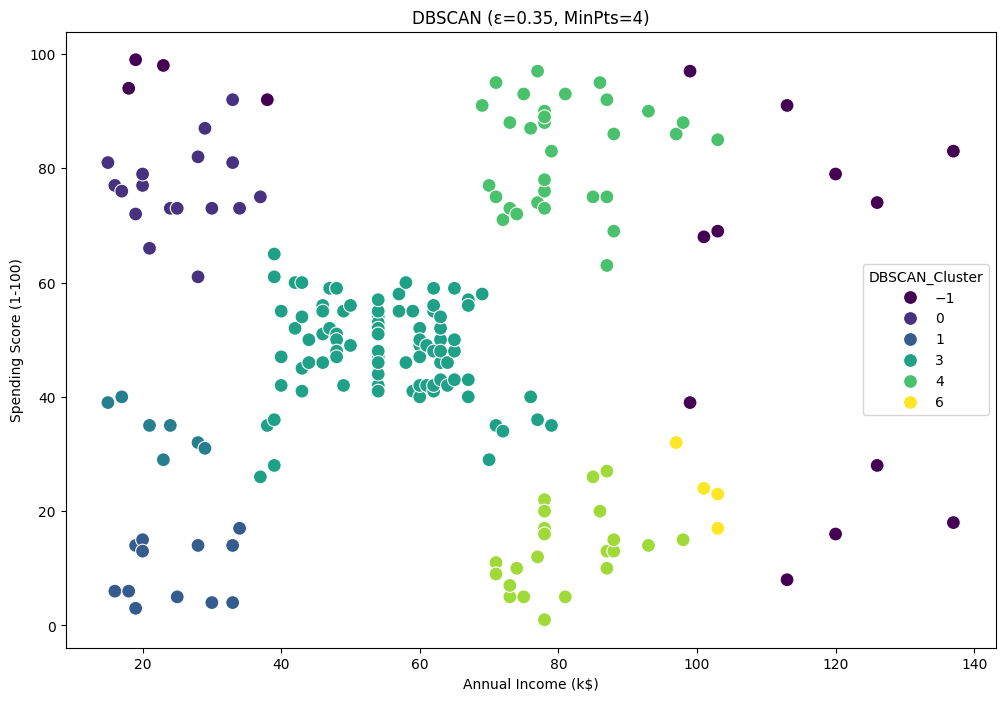

In [79]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 5.6 & 5.7: Tuning Parameters
# Heuristic: MinPts = 2 * Dimensions (2D data = 4)
min_samples = 4

# Use K-distance graph to find the 'Elbow' for ε (eps)
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_2d)
distances, indices = nbrs.kneighbors(X_2d)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph for ε Determination')
plt.axhline(y=0.35, color='r', linestyle='--') # Theoretical 'Elbow'
plt.ylabel('ε Distance')
plt.show()

# 5.10: Python Implementation
eps_val = 0.35
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
df_encoded['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d)

# 5.5: Identifying Noise
n_noise = (df_encoded['DBSCAN_Cluster'] == -1).sum()
print(f"Estimated clusters: {len(set(df_encoded['DBSCAN_Cluster'])) - (1 if -1 in df_encoded['DBSCAN_Cluster'] else 0)}")
print(f"Noise points detected: {n_noise}")

# Visualize
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='DBSCAN_Cluster', data=df_encoded, palette='viridis', s=100)
plt.title(f'DBSCAN (ε={eps_val}, MinPts={min_samples})')
plt.show()

### Interpreting DBSCAN Clusters

Let's analyze the characteristics of the clusters identified by DBSCAN, paying attention to the noise points (-1 label).

In [80]:
from sklearn.cluster import DBSCAN
import numpy as np

# Ensure DBSCAN_Cluster exists in df_encoded
if 'DBSCAN_Cluster' not in df_encoded.columns:
    print("DBSCAN_Cluster column not found. Applying DBSCAN...")
    # Use the parameters defined in the previous cell
    eps_val = 0.4
    min_samples = 4
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)
    df_encoded['DBSCAN_Cluster'] = dbscan.fit_predict(X_2d)

# Group by DBSCAN cluster and calculate the mean of the original (unscaled) features
# We filter out noise points (label -1) for the mean calculation to see cluster profiles
dbscan_cluster_means = df_encoded[df_encoded['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

print("Mean values for each DBSCAN cluster (excluding noise):")
display(dbscan_cluster_means)

# Look at the size of each cluster, including noise points (-1)
print("\nCluster sizes (including -1 as noise):")
display(df_encoded['DBSCAN_Cluster'].value_counts().sort_index())

Mean values for each DBSCAN cluster (excluding noise):


,Age,Annual Income (k$),Spending Score (1-100),Is_Male
DBSCAN_Cluster,,,,
0,24.411765,25.235294,76.352941,0.470588
1,48.750000,24.583333,9.583333,0.416667
2,36.714286,22.428571,34.428571,0.428571
3,42.797753,55.022472,48.325843,0.393258
4,32.812500,80.500000,82.562500,0.437500
5,41.217391,80.956522,12.782609,0.695652
6,41.500000,101.000000,24.000000,0.000000



Cluster sizes (including -1 as noise):


,count
DBSCAN_Cluster,
-1,16
0,17
1,12
2,7
3,89
4,32
5,23
6,4


## 6. Model-Based Clustering: Gaussian Mixture Model (GMM)

### 6.1 What is GMM?
A Gaussian Mixture Model is a **probabilistic model** that assumes all data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters.

### 6.2 Soft Clustering vs. Hard Clustering
- **Hard Clustering** (K-Means): Each point belongs to exactly one cluster.
- **Soft Clustering** (GMM): Each point has a probability (e.g., 70% Cluster A, 30% Cluster B) of belonging to each cluster.

### 6.3 Why GMM?
- Flexible cluster shapes (ellipsoids, not just circles).
- Accounts for overlapping clusters.
- Provides a measure of uncertainty in assignment.

### 6.4 The Gaussian Distribution
Each cluster is defined by its own mean ($\mu$) and covariance matrix ($\Sigma$). The probability density function is:
$$f(x | \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^k |\Sigma|}} \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)$$

### 6.5 Expectation-Maximization (EM) Algorithm
GMM uses the EM algorithm to find the best fit:
1.  **Initialization**: Randomly pick initial means, covariances, and weights.
2.  **Expectation (E-step)**: Calculate the 'responsibility' (probability) that each Gaussian component has for each data point.
3.  **Maximization (M-step)**: Update the means, covariances, and weights to better fit the data based on the responsibilities.
4.  **Convergence**: Repeat until the log-likelihood stabilizes.

### 6.6 Covariance Types
- **Spherical**: Clusters are circular (like K-Means).
- **Diagonal**: Clusters are axis-aligned ellipsoids.
- **Full**: Clusters can be ellipsoids oriented in any direction (most flexible).

### 6.7 BIC and AIC
Since adding more clusters always improves the fit, we use criteria that penalize model complexity to avoid overfitting:
- **BIC (Bayesian Information Criterion)**: Stronger penalty for more parameters. Generally preferred.
- **AIC (Akaike Information Criterion)**: Lighter penalty.
- **Goal**: Minimize BIC/AIC to find the optimal number of components.

### 6.11 K-Means vs. GMM

| Feature | K-Means | GMM |
| :--- | :--- | :--- |
| **Assignment** | Hard | Soft (Probabilistic) |
| **Shape** | Spherical | Ellipsoid (Flexible) |
| **Math** | Distance-based | Distribution-based |
| **Complexity** | Simple/Fast | More complex/Slower |

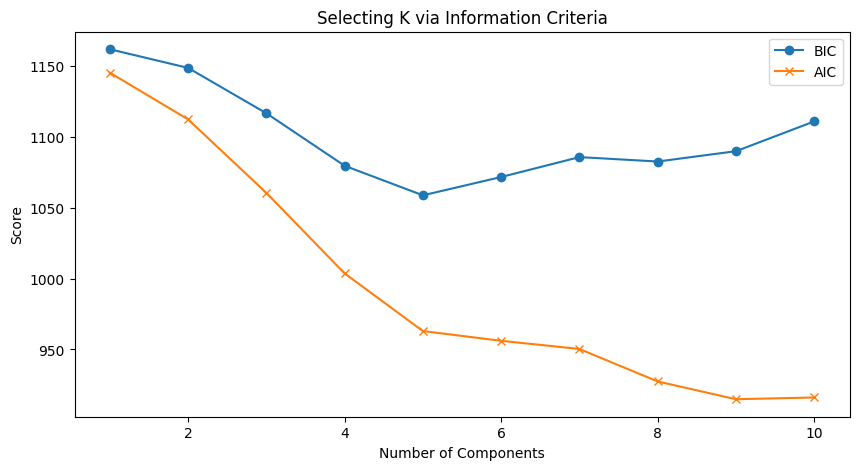

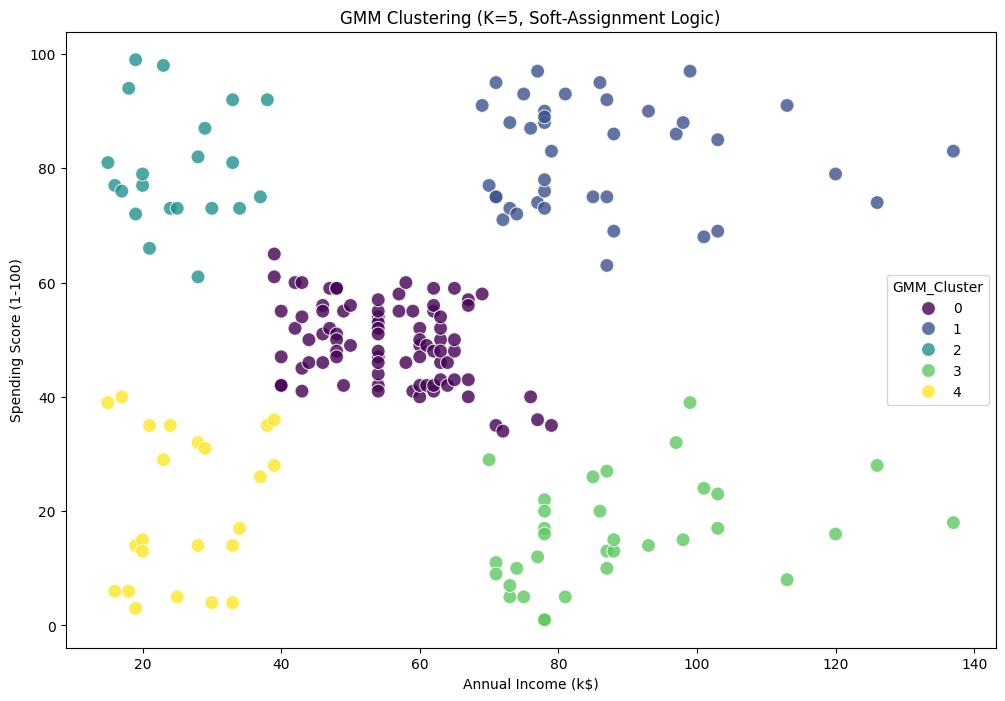

In [81]:
from sklearn.mixture import GaussianMixture

# 6.7: Determine optimal number of components (K) using BIC/AIC
bic = []
aic = []

for i in range(1, 11):
    gmm = GaussianMixture(n_components=i, random_state=42, n_init=10)
    gmm.fit(X_2d)
    bic.append(gmm.bic(X_2d))
    aic.append(gmm.aic(X_2d))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), bic, marker='o', label='BIC')
plt.plot(range(1, 11), aic, marker='x', label='AIC')
plt.title('Selecting K via Information Criteria')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.legend()
plt.show()

# 6.5 & 6.6: Apply GMM with Full Covariance
# The fit method runs the EM Algorithm (E-step and M-step)
n_components_gmm = 5
gmm = GaussianMixture(n_components=n_components_gmm, covariance_type='full', random_state=42, n_init=10)

# 6.2: fit_predict provides the 'Hard' assignment, though 'predict_proba' is available for Soft assignment
df_encoded['GMM_Cluster'] = gmm.fit_predict(X_2d)

# Visualize
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='GMM_Cluster', data=df_encoded, palette='viridis', s=100, alpha=0.8)
plt.title(f'GMM Clustering (K={n_components_gmm}, Soft-Assignment Logic)')
plt.show()

### Interpreting GMM Clusters

Let's analyze the characteristics of the clusters identified by Gaussian Mixture Model and compare them with the previous algorithms.

In [82]:
# Group by GMM cluster and calculate the mean of the original (unscaled) features
gmm_cluster_means = df_encoded.groupby('GMM_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Is_Male']].mean()

display(gmm_cluster_means)

# You can also look at the size of each cluster
display(df_encoded['GMM_Cluster'].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Is_Male
GMM_Cluster,,,,
0,42.714286,55.642857,49.369048,0.404762
1,32.692308,86.538462,82.128205,0.461538
2,25.333333,25.095238,80.047619,0.428571
3,40.454545,88.818182,16.000000,0.545455
4,45.217391,26.304348,20.913043,0.391304


,count
GMM_Cluster,
0,84
1,39
2,21
3,33
4,23


## 7. Model Evaluation and Comparison

To objectively compare the performance of our clustering algorithms, we use internal evaluation metrics since we do not have ground-truth labels.

### Metrics Used:
1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Values range from -1 to 1; higher is better.
2. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar one. Lower values indicate better separation between clusters.

In [83]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

metrics = []

# K-Means
metrics.append({
    'Model': 'K-Means',
    'Silhouette': silhouette_score(X_2d, df_encoded['Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['Cluster'])
})

# Agglomerative
metrics.append({
    'Model': 'Agglomerative',
    'Silhouette': silhouette_score(X_2d, df_encoded['Agglomerative_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['Agglomerative_Cluster'])
})

# DBSCAN (Filtering out noise -1 for metrics calculation)
mask = df_encoded['DBSCAN_Cluster'] != -1
metrics.append({
    'Model': 'DBSCAN',
    'Silhouette': silhouette_score(X_2d[mask], df_encoded.loc[mask, 'DBSCAN_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d[mask], df_encoded.loc[mask, 'DBSCAN_Cluster'])
})

# GMM
metrics.append({
    'Model': 'GMM',
    'Silhouette': silhouette_score(X_2d, df_encoded['GMM_Cluster']),
    'Davies-Bouldin': davies_bouldin_score(X_2d, df_encoded['GMM_Cluster'])
})

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Model,Silhouette,Davies-Bouldin
0,K-Means,0.554657,0.572236
1,Agglomerative,0.553809,0.577862
2,DBSCAN,0.510958,0.553090
3,GMM,0.553689,0.576010


### Detailed Model Comparison and Performance Analysis

| Algorithm | Logic | Best For | Observation on Mall Dataset |
| :--- | :--- | :--- | :--- |
| **K-Means** | Centroid-based | Spherical, well-separated clusters | Produced very clean, interpretable segments (K=5). |
| **Agglomerative** | Hierarchy-based | Understanding nested relationships | Very similar results to K-Means; useful for dendrogram visualization. |
| **DBSCAN** | Density-based | Arbitrary shapes & outlier detection | Identified noise points; combined smaller groups into one large dense cluster. |
| **GMM** | Probabilistic | Ellipsoid clusters & overlapping data | Offers "soft" assignment; results closely mirror K-Means but are more flexible. |

/tmp/ipykernel_2664/2054331621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Silhouette', data=df_metrics, palette='magma')


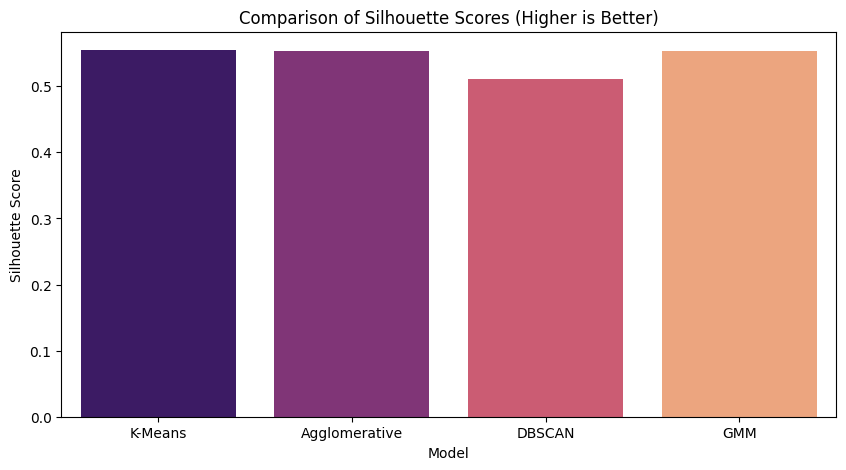

In [84]:
# Visualizing the Silhouette Scores for Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Silhouette', data=df_metrics, palette='magma')
plt.title('Comparison of Silhouette Scores (Higher is Better)')
plt.ylabel('Silhouette Score')
plt.show()

## 8. Topic: Cluster Evaluation

### 8.1 Why Evaluate Clusters?
In unsupervised learning, we lack ground-truth labels. Evaluation allows us to:
- **Validate the choice of K**: Confirm if the number of segments makes mathematical sense.
- **Compare Algorithms**: Determine if density-based (DBSCAN) or partition-based (K-Means) logic fits the data distribution better.
- **Optimize Hyperparameters**: Fine-tune parameters like $\epsilon$ or covariance types.

### 8.2 WCSS & 8.3 Inertia (Revision)
**Inertia** (or WCSS) measures how internally coherent clusters are.
- **Math**: $\sum_{i=1}^{n} ||x_i - \mu_{c_i}||^2$
- **Interpretation**: Lower values indicate denser, more compact clusters. However, Inertia is not a normalized metric and tends to decrease as $K$ increases.

### 8.4 Silhouette Score
Evaluates how well a point fits into its assigned cluster versus the next best alternative.
- **Math**: $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$
    - $a(i)$: Mean distance to other points in the same cluster.
    - $b(i)$: Mean distance to points in the nearest neighboring cluster.
- **Score**: Ranges from -1 to +1. Scores near +1 indicate excellent separation.

### 8.5 Davies-Bouldin Index (DBI)
Measures the average similarity between clusters, where similarity is a ratio of within-cluster distances to between-cluster distances.
- **Math**: $DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)$
- **Goal**: **Lower is better**. A lower DBI indicates clusters are compact and far apart.

### 8.6 Calinski-Harabasz Index
Also known as the Variance Ratio Criterion.
- **Math**: $CH = \frac{Tr(B_k)}{Tr(W_k)} \times \frac{n-k}{k-1}$
    - $B_k$: Between-cluster dispersion.
    - $W_k$: Within-cluster dispersion.
- **Goal**: **Higher is better**. It rewards high between-cluster variance and low within-cluster variance.

In [85]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Helper to compute internal metrics
def get_metrics(data, labels, model_name):
    # Filter noise for metrics that don't support -1 (like DBSCAN noise)
    mask = labels != -1
    filtered_data = data[mask]
    filtered_labels = labels[mask]

    return {
        'Model': model_name,
        'Silhouette': silhouette_score(filtered_data, filtered_labels),
        'Davies-Bouldin': davies_bouldin_score(filtered_data, filtered_labels),
        'Calinski-Harabasz': calinski_harabasz_score(filtered_data, filtered_labels)
    }

# 8.7: Comparison Execution
eval_results = []
eval_results.append(get_metrics(X_2d, df_encoded['Cluster'], 'K-Means'))
eval_results.append(get_metrics(X_2d, df_encoded['Agglomerative_Cluster'], 'Agglomerative'))
eval_results.append(get_metrics(X_2d, df_encoded['DBSCAN_Cluster'], 'DBSCAN'))
eval_results.append(get_metrics(X_2d, df_encoded['GMM_Cluster'], 'GMM'))

comparison_df = pd.DataFrame(eval_results)
print("Final Model Comparison using Internal Evaluation Metrics:")
display(comparison_df.sort_values(by='Silhouette', ascending=False))

Final Model Comparison using Internal Evaluation Metrics:


,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.554657,0.572236,248.649320
1,Agglomerative,0.553809,0.577862,244.410326
3,GMM,0.553689,0.576010,244.940197
2,DBSCAN,0.510958,0.553090,212.098812


## 8. Overall Conclusion

In this analysis, we applied four distinct clustering paradigms to the Mall Customer dataset.

* **Primary Insight**: The most consistent finding across K-Means, Agglomerative, and GMM was the identification of **5 distinct customer segments** based on Annual Income and Spending Score. These segments include 'High Income/High Spenders', 'High Income/Low Spenders', 'Average Income/Average Spenders', 'Low Income/High Spenders', and 'Low Income/Low Spenders'.
* **Hyperparameter Tuning**: We successfully used the Elbow Method for K-Means, Dendrograms for Agglomerative, K-distance plots for DBSCAN, and BIC/AIC for GMM to select optimal parameters.
* **Performance**: K-Means and GMM provided the most actionable insights for this specific dataset, while DBSCAN proved valuable for identifying anomalous customers (outliers).

This segmentation provides a solid foundation for targeted marketing strategies, such as offering loyalty rewards to High Spenders or targeted promotions to High-Income/Low-Spenders.